## Chapter 5

### Question 5

In [240]:
# Imports
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [95]:
# Load dataset
default = pd.read_csv('data/Default.csv')

# Check dataset's basic info
default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [96]:
# Check first observations
default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [97]:
# Adapt response dummy - 'default'
default['default'] = default['default'].apply(
    lambda x: 1 if x=='Yes' else 0
)

# Adapt dummy 'student'
default['student'] = default['student'].apply(
    lambda x: 1 if x=='Yes' else 0
)

#### 5a)


Fitting a logistic regression model on the entire dataset.

In [98]:
# Create dataset for validation approach
X = default[['balance', 'income']]
X.insert(0, 'intercept', np.ones(len(X)))
y = default['default']

In [99]:
# Create and fit a logistic regression
model = sm.GLM(y, X, sm.families.Binomial()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Sun, 10 Nov 2024   Deviance:                       1579.0
Time:                        15:47:12   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.5405      0.435    -26.544      0.000     -12.393     -10.688
balance        0.0056      0.000     24.835      0.000       0.005       0.006
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
==============================================================================
"""

#### 5b)


Now, we will fit the model and compute the validation set error.

In [100]:
# Test size for validation
test_size = 0.5

# Split data for validation
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=test_size, 
    random_state=0
)

In [101]:
# Create and fit a logistic regression
model = sm.GLM(y_train, X_train, sm.families.Binomial()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                 5000
Model:                            GLM   Df Residuals:                     4997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -364.78
Date:                Sun, 10 Nov 2024   Deviance:                       729.56
Time:                        15:47:12   Pearson chi2:                 2.57e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1125
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.3896      0.635    -17.935      0.000     -12.634     -10.145
balance        0.0056      0.000     16.792      0.000       0.005       0.006
income       1.58e-05   7.34e-06      2.151      0.031     1.4e-06    3.02e-05
==============================================================================
"""

In [102]:
# Predict on the test/validation set
pred = model.predict(X_test)

# Adept prediction probabilities
pred = pred.apply(lambda x: 1 if x>0.5 else 0)

In [103]:
# Compute the validation acc
pred_correct = sum(np.array(pred) == np.array(y_test))
acc = (pred_correct / len(X_test))*100

# Compute validation error
pred_incorrect = sum(np.array(pred) != np.array(y_test))
error = (pred_incorrect / len(X_test))*100

# Print info
print(f"""
Logistic Acc:  \t{acc:.2f}%
Logistic Error:\t{error:.2f}%
""")


Logistic Acc:  	97.10%
Logistic Error:	2.90%



#### 5c)


Below, we split the dataset 3x into train and validation samples before training a logistic regression model. It is possible to notice that we get a different error rate each time we perform a training loop.

In [104]:
# Loop 3x repeating 5b)
for i in range(1, 4):
    
    # Split the sample
    X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        test_size=test_size
    )

    # Create and fit the model
    model = sm.GLM(y_train, X_train, sm.families.Binomial()).fit()

    # Predict on validation/test dataset
    pred = model.predict(X_test)
    pred = pred.apply(lambda x: 1 if x>0.5 else 0)

    # Compute error
    error = sum(np.array(pred) != np.array(y_test))
    error_rate = (error / len(X_test))*100

    # Print info
    print(f"""
    Model:     \t{i}
    Error Rate:\t{error_rate:.2f}%
    """)


    Model:     	1
    Error Rate:	2.58%
    

    Model:     	2
    Error Rate:	2.64%
    

    Model:     	3
    Error Rate:	2.80%
    


#### 5d)


Including feature/variable 'student' to the logistic regression improves model's error rate.

In [105]:
# Create dataset for validation approach
X = default[['balance', 'income', 'student']]
X.insert(0, 'intercept', np.ones(len(X)))
y = default['default']

In [106]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=42
)

# Create and fit the model
model = sm.GLM(y_train, X_train, sm.families.Binomial()).fit()

# Look at the summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                 5000
Model:                            GLM   Df Residuals:                     4996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -389.50
Date:                Sun, 10 Nov 2024   Deviance:                       779.00
Time:                        15:47:12   Pearson chi2:                 4.39e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1361
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.1580      0.712    -15.679      0.000     -12.553      -9.763
balance        0.0061      0.000     17.561      0.000       0.005       0.007
income      -2.87e-06   1.15e-05     -0.250      0.803   -2.54e-05    1.96e-05
student       -0.8090      0.330     -2.448      0.014      -1.457      -0.161
==============================================================================
"""

In [107]:
# Predict on validation dataset
pred = model.predict(X_test)
pred = pred.apply(lambda x: 1 if x>50 else 0)

# Compute error rate
error = sum(np.array(pred) != np.array(y_test))
error_rate = error / len(X_test)

# Print info
print(f"""
Error Rate:\t{error_rate:.2f}%
""")


Error Rate:	0.03%



---

### Question 6

In [158]:
# Basic info
default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  int64  
 1   student  10000 non-null  int64  
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


In [159]:
# Create datasets
X = default[['income', 'balance']]
X.insert(0, 'intercept', np.ones(len(X)))
y = default['default']

#### 6a)

In [160]:
# Create & fit a logist regression model
model = sm.GLM(y, X, sm.families.Binomial()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Sun, 10 Nov 2024   Deviance:                       1579.0
Time:                        23:11:46   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.5405      0.435    -26.544      0.000     -12.393     -10.688
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
balance        0.0056      0.000     24.835      0.000       0.005       0.006
==============================================================================
"""

In [161]:
# Get the standard errors of the parameter estimates
model.bse

intercept    0.434772
income       0.000005
balance      0.000227
dtype: float64

In [162]:
model.params.item

<bound method IndexOpsMixin.item of intercept   -11.540468
income        0.000021
balance       0.005647
dtype: float64>

In [163]:
type(model.params)

pandas.core.series.Series

#### 6b)

In [164]:
# Create a function that outputs a logistic regression coefficients
def boot_fn(df, idx):
    
    # Get the relevant features/variables
    X_ = df[['income', 'balance']]
    X_.insert(0, 'intercept', np.ones(len(df)))
    y_ = df['default']
    
    # Get the index
    X_ = X_.loc[idx]
    y_ = y_.loc[idx]

    # Create and fit the model
    model_ = sm.GLM(y_, X_, sm.families.Binomial()).fit()

    # Get the coefficients
    params_ = model_.params

    return params_

In [165]:
# Test function
boot_fn(default, range(500))

intercept   -11.678916
income        0.000025
balance       0.005774
dtype: float64

#### 6c)

In [166]:
# Create a bootstrap logistic function
def boot_se(
    func,
    df,
    n=None, # sample size
    b=1000, # number of iterations
    seed=0
):
    # Set seed
    rng = np.random.default_rng(seed)

    # Initialize variables
    first_, second_ = 0, 0
    n = n or df.shape[0]

    # Loop b times
    for _ in range(b):
        idx = rng.choice(df.index, n, replace=True)
        value = func(df, idx)
        first_ += value
        second_ += value**2

    # Compute standard error
    se = np.sqrt(
        (second_ / b) - (first_ / b)**2
    )
    return se

In [167]:
# Test function
boot_se(boot_fn, default, b=1000, seed=0)

intercept    0.435692
income       0.000005
balance      0.000230
dtype: float64

#### 6d)

The standard errors computed using the bootstrap method are quite similar to those obtained from the sm.GLM() function. This is likely due to the relatively large size of our dataset, which consists of 10,000 observations. However, if we were to use a smaller sample, the results might differ.

Have a look at how the logistic model with a smaller sample size has much more variance on its results when compared to the same sample size when using bootstrap.

In [179]:
# Set seed
rng = np.random.default_rng(42)

# Fitting smaller samples with logistic regression
for i in range(3):
    # Sample
    idx = rng.choice(X.index, 1000, replace=True)
    # Create and fit the model
    model = sm.GLM(y.loc[idx], X.loc[idx], sm.families.Binomial()).fit()
    # Print std errors
    print(f'\nmodel {i+1} std erros:\n\n{model.bse}')
    print('\n----------------------------------')


model 1 std erros:

intercept    2.234488
income       0.000019
balance      0.001127
dtype: float64

----------------------------------

model 2 std erros:

intercept    1.559257
income       0.000016
balance      0.000800
dtype: float64

----------------------------------

model 3 std erros:

intercept    1.371838
income       0.000016
balance      0.000656
dtype: float64

----------------------------------


In [181]:
# Bootstrap with smaller samples
for i in range(3):
    print(f'\nbootstrap {i+1} std errors:\n')
    print(boot_se(boot_fn, default, n=1000, b=1000, seed=i))
    print('\n----------------------------------')


bootstrap 1 std errors:

intercept    1.532829
income       0.000016
balance      0.000817
dtype: float64

----------------------------------

bootstrap 2 std errors:

intercept    1.547043
income       0.000016
balance      0.000792
dtype: float64

----------------------------------

bootstrap 3 std errors:

intercept    1.487063
income       0.000017
balance      0.000767
dtype: float64

----------------------------------


---

### Question 7

In [184]:
# Load dataset
weekly = pd.read_csv('data/Weekly.csv')

# Quick info
weekly.info()

# Check first observations
weekly.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [188]:
# Prepare the dataset
weekly.columns = [x.lower() for x in weekly.columns]

# Get the relevant columns
X = weekly[['lag1', 'lag2']]
X.insert(0, 'intercept', np.ones(len(X)))
y = weekly['direction']

# Transform y into dummy
y = y.apply(lambda x: 1 if x=='Up' else 0)

#### 7a)

In [189]:
# Create and fit a logistic regression
model = sm.GLM(y, X, sm.families.Binomial()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1086
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -744.11
Date:                Mon, 11 Nov 2024   Deviance:                       1488.2
Time:                        18:51:05   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007303
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2212      0.061      3.599      0.000       0.101       0.342
lag1          -0.0387      0.026     -1.477      0.140      -0.090       0.013
lag2           0.0602      0.027      2.270      0.023       0.008       0.112
==============================================================================
"""

#### 7b)

In [193]:
# Predict on all but first observation
idx = range(1, len(X))
model = sm.GLM(y.loc[idx], X.loc[idx], sm.families.Binomial()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              direction   No. Observations:                 1088
Model:                            GLM   Df Residuals:                     1085
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.26
Date:                Mon, 11 Nov 2024   Deviance:                       1486.5
Time:                        18:51:56   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007373
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2232      0.061      3.630      0.000       0.103       0.344
lag1          -0.0384      0.026     -1.466      0.143      -0.090       0.013
lag2           0.0608      0.027      2.291      0.022       0.009       0.113
==============================================================================
"""

#### 7c)

The model's prediction on the first observation is not correct. It predicts the direcation is 'Up' (dummy=1), but the correct label is 'Down' (dummy=0).

In [221]:
# Predict on the first observation
pred = model.predict(X.loc[0]).apply(lambda x: 1 if x>0.5 else 0)

# Check if the prediction is correct
print(pred == y.loc[0])

None    False
dtype: bool


In [222]:
print(f"""
Predicted obs: {pred.item()}
Correct label: {y.loc[0]}
""")


Predicted obs: 1
Correct label: 0



#### 7d)

In [232]:
# Initialize an error list
error_list = []

# Create a loop for LOOCV
for i in range(len(y)):
    idx = [x for x in y.index if x != i]
    # Create and fit the model
    model = sm.GLM(y.loc[idx], X.loc[idx], sm.families.Binomial()).fit()
    # Predict
    pred = model.predict(X.loc[i]).apply(lambda x: 1 if x>0.5 else 0)
    # Add errors
    if pred.item() != y.loc[i]:
        error_list.append(1)
    else:
        error_list.append(0)

#### 7e)

The logistic regression model evaluated using the LOOCV method shows an error rate of 45%. This indicates that the model incorrectly predicts whether the direction is 'up' or 'down' 45% of the time.

This suggests that the model is either failing to capture meaningful patterns in the data or that there may not be patterns to learn for accurate predictions.

In [238]:
# Compute model's error rate when using LOOCV
error_rate = round((sum(error_list) / len(error_list))*100, 2)

# Print info
print(f"""
Error rate: {error_rate}%
""")


Error rate: 45.0%



---

### Question 8

#### 8a)

Below, we are generating a dataset with 100 observations, where 'p' is equal to 2 features.

$$
y = x - 2x^2
$$

In [239]:
# Generate a simulated dataset
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

#### 8b)

The scatterplot below illustrates the data generated using the quadratic formula. The curve exhibits a maximum point due to the negative coefficient of the quadratic term, indicating a downward-opening parabola. It is possible to see a certain amount of dispersion in the data due to the randomness of the error term.

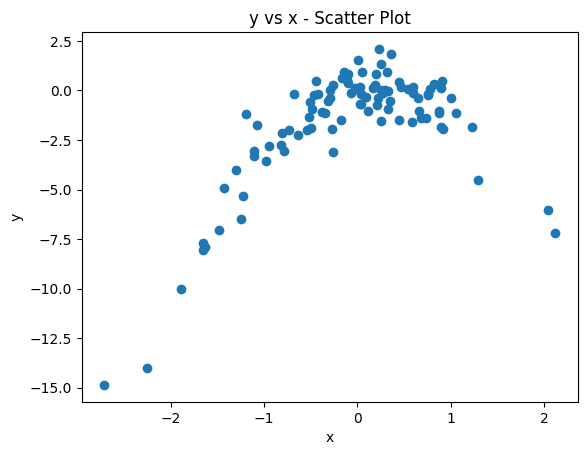

In [280]:
# Create a scatterplot
plt.figure(dpi=100)
plt.scatter(x, y)
plt.title('y vs x - Scatter Plot')
plt.ylabel('y')
plt.xlabel('x');

#### 8c)

In [267]:
# Create datasets for the models
X1 = pd.DataFrame(x, columns=['x'])
X1.insert(0, 'intercept', np.ones(len(X1)))

X2 = X1.copy()
X2.insert(2, 'x^2', x**2)

X3 = X2.copy()
X3.insert(3, 'x^3', x**3)

X4 = X3.copy()
X4.insert(4, 'x^4', x**4)

In [291]:
# Initialize error lists
error1_list = []
error2_list = []
error3_list = []
error4_list = []

# fit a linear regression model to each dataset using LOOCV
for i in X1.index:
    idx = [x for x in X1.index if x != i]
    model1 = sm.OLS(y[idx], X1.loc[idx]).fit()
    pred1 = model1.predict(X1.loc[i])
    error1 = (y[i] - pred1)**2
    error1_list.append(error1)

    model2 = sm.OLS(y[idx], X2.loc[idx]).fit()
    pred2 = model2.predict(X2.loc[i])
    error2 = (y[i] - pred2)**2
    error2_list.append(error2)

    model3 = sm.OLS(y[idx], X3.loc[idx]).fit()
    pred3 = model3.predict(X3.loc[i])
    error3 = (y[i] - pred3)**2
    error3_list.append(error3)

    model4 = sm.OLS(y[idx], X4.loc[idx]).fit()
    pred4 = model4.predict(X4.loc[i])
    error4 = (y[i] - pred4)**2
    error4_list.append(error4)

# Print information
print(f"""
model1 mse: {np.mean(error1_list):.2f}
model2 mse: {np.mean(error2_list):.2f}
model3 mse: {np.mean(error3_list):.2f}
model4 mse: {np.mean(error4_list):.2f}
""")


model1 mse: 6.63
model2 mse: 1.12
model3 mse: 1.30
model4 mse: 1.33



#### 8d)

There's no need to generate a random seed when performing LOOCV. This method itertes over the entire dataset, leaving out one observation at a time for testing while using the rest for training.

Since every observation is eventually used as a test case, the process will produce the same MSE regardless of the starting point. The results are not affected by randomization.

#### 8e)

The lowest MSE was achieved by model2, which corresponds to a quadratic function:
$$
y = B_0 + B_1x + B_2x^2
$$

This outcome is expected, as this model aligns with the true underlying data. The only variation, or exception, comes from the intercept, as the generated data does not have one.

#### 8f)

Examining the p-values of each model's parameters reveals that the results generally align with the conclusion drawn from cross-validation. However, there is one notable exception: the forth model (model4), which include an x^4 term, shows this parameter as statistically significant. This suggests that model4 might be capturing addtional information that the other models miss, which theoretically should lead to a lower MSE.

However, this improvement in fit does not translate into better model performance or accuracy. Instead, the MSE increases. This discrepancy is likely a sign of overfitting, where model4 captures noise rather than meaningful patterns in the data.

In [304]:
# Check model1's pvalues
round(model1.pvalues, 4)

intercept    0.0
x            0.0
dtype: float64

In [305]:
# Check model2's pvalues
round(model2.pvalues, 4)

intercept    0.6176
x            0.0000
x^2          0.0000
dtype: float64

In [306]:
# Check model2's pvalues
round(model3.pvalues, 4)

intercept    0.7231
x            0.0000
x^2          0.0000
x^3          0.2632
dtype: float64

In [307]:
# Check model2's pvalues
round(model4.pvalues, 4)

intercept    0.3926
x            0.0000
x^2          0.0000
x^3          0.6685
x^4          0.0218
dtype: float64

---

### Question 9



In [310]:
# Load Boston dataset
boston = pd.read_csv('data/Boston.csv')

# Drop first column
boston = boston.iloc[:, 1:]

# Quick info
boston.info()

# Check first observations
boston.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


#### 9a)

In [372]:
# Mean estimation for medv (p236)
mu = boston['medv'].mean()
round(mu, 4)

22.5328

#### 9b)

In [336]:
# Compute deviations
deviation_list = []
for idx in boston.index:
    # Get the observation's value
    medv = boston.loc[idx]['medv']
    # Compute the deviation
    deviation = (medv - mu)**2
    deviation_list.append(deviation)

# Compute standard deviation
sigma = np.sqrt(sum(deviation_list) / (len(deviation_list) - 1))
round(sigma, 4)

9.1971

In [337]:
# Compute standard error
se = sigma / np.sqrt(len(deviations_list))
round(se, 4)

0.4089

#### 9c)

When we compute the standard error of mu using the bootstrap, we get a slightly higher value of 0.4127 when compared to the previous value of 0.4089. This reinforces the metric we have for standard error of the estimated mean (mu),

In [375]:
# Compute standard error of mu using bootstrap
rng = np.random.default_rng(0)
mu_boot = []
b = 1000
for i in range(b):
    idx = rng.choice(boston.index, boston.shape[0], replace=True)
    # Get the observation
    mu_i = boston.loc[idx]['medv'].mean()
    mu_boot.append(mu_i)

In [376]:
# Estimate mean
mu = sum(mu_boot) / len(mu_boot)

# Compute deviation
deviation = [(x - mu)**2 for x in mu_boot]

# Compute standard error
se = np.sqrt(sum(deviation) / (len(deviation) - 1))
round(se, 4)

0.4127

In [380]:
models = 0
for i in range(1, 21):
    models += i

models + 1 #the null model

211